<a href="https://colab.research.google.com/github/novalrnv/machine_learning/blob/main/KUIS/KUIS1_244107020210_Khoirul%20Umam%20Novalidi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [4]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [5]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [6]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [7]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
# Data Size
df.shape

(48842, 15)

In [9]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [16]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
adult_income = fetch_ucirepo(id=2)
X = adult_income.data.features
y = adult_income.data.targets
df = pd.concat([X, y], axis=1)

df_missing_rows = df[df.isnull().any(axis=1)]

print("Tabel data yang mengandung nilai kosong (missing values):")
display(df_missing_rows.head())

missing_values = df.isnull().sum()
missing_only = missing_values[missing_values > 0]

print("\nVariabel yang memiliki missing value dan jumlahnya:")
for col, count in missing_only.items():
  print(f"- {col}: {count} data kosong")

Tabel data yang mengandung nilai kosong (missing values):


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32565,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.
32567,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K.
32574,58,NaN,299831,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K.
32580,40,Private,85019,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,45,NaN,>50K.
32583,72,NaN,132015,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K.



Variabel yang memiliki missing value dan jumlahnya:
- workclass: 963 data kosong
- occupation: 966 data kosong
- native-country: 274 data kosong


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [18]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

df_imputed = df.copy()

for col in ['workclass', 'occupation', 'native-country']:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)

remaining_missing = df_imputed.isnull().sum()
print("Jumlah missing value setelah imputasi:")
print(remaining_missing)

Jumlah missing value setelah imputasi:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [22]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
categorical_cols = df_imputed.select_dtypes(include=['object']).columns

print(f"{'NILAI UNIK SEBELUM PEMBERSIHAN':^80}")
for col in categorical_cols:
    unique_vals = df_imputed[col].unique()
    total_uniq = df_imputed[col].nunique()
    preview = ", ".join([f"'{val}'" for val in unique_vals[:8]])
    if len(unique_vals) > 8:
        preview += " ..."
    print(f"- {col:<15} ({total_uniq:<2} unik) : {preview}")

for col in categorical_cols:
    df_imputed[col] = df_imputed[col].astype(str).str.strip().str.rstrip('.')

print()
print(f"{'NILAI UNIK SETELAH PEMBERSIHAN':^80}")
for col in categorical_cols:
    unique_vals = df_imputed[col].unique()
    total_uniq = df_imputed[col].nunique()
    preview = ", ".join([f"'{val}'" for val in unique_vals[:8]])
    if len(unique_vals) > 8:
        preview += " ..."
    print(f"- {col:<15} ({total_uniq:<2} unik) : {preview}")
print("=" * 80)

                         NILAI UNIK SEBELUM PEMBERSIHAN                         
- workclass       (9  unik) : 'State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', 'Local-gov', '?', 'Self-emp-inc', 'Without-pay' ...
- education       (16 unik) : 'Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college', 'Assoc-acdm', 'Assoc-voc' ...
- marital-status  (7  unik) : 'Never-married', 'Married-civ-spouse', 'Divorced', 'Married-spouse-absent', 'Separated', 'Married-AF-spouse', 'Widowed'
- occupation      (15 unik) : 'Adm-clerical', 'Exec-managerial', 'Handlers-cleaners', 'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair', 'Transport-moving' ...
- relationship    (6  unik) : 'Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried', 'Other-relative'
- race            (5  unik) : 'White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other'
- sex             (2  unik) : 'Male', 'Female'
- native-country  (42 unik) : 'United-States', 'Cuba', 'Jamaica', 'India', '?

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

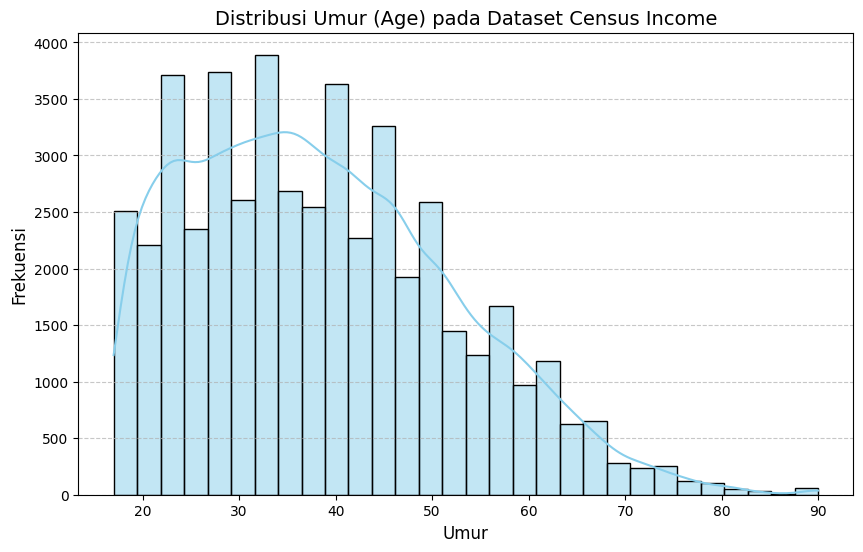

In [23]:
# Jawab 1.1 - Histogram
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_imputed, x='age', kde=True, color='skyblue', bins=30)
plt.title('Distribusi Umur (Age) pada Dataset Census Income', fontsize=14)
plt.xlabel('Umur', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2935/443264087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_imputed, y='education', order=df_imputed['education'].value_counts().index, palette='viridis')


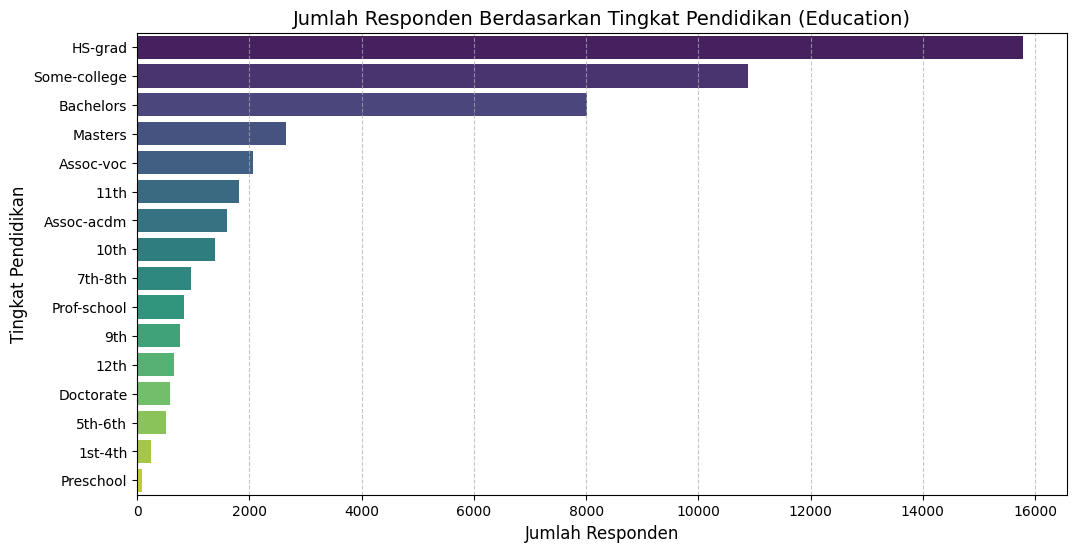

In [24]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(12, 6))
sns.countplot(data=df_imputed, y='education', order=df_imputed['education'].value_counts().index, palette='viridis')
plt.title('Jumlah Responden Berdasarkan Tingkat Pendidikan (Education)', fontsize=14)
plt.xlabel('Jumlah Responden', fontsize=12)
plt.ylabel('Tingkat Pendidikan', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2935/3340842033.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_imputed, x='income', y='hours-per-week', palette='Set2')


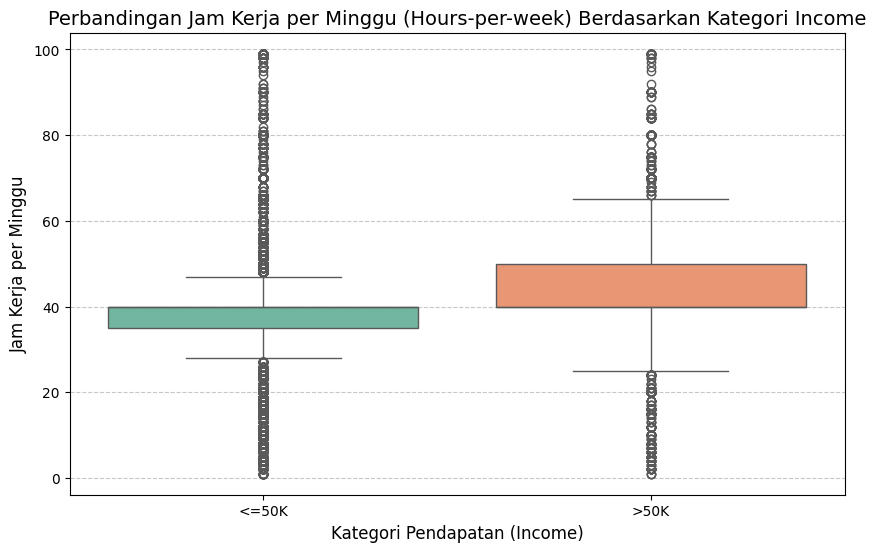

In [25]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_imputed, x='income', y='hours-per-week', palette='Set2')
plt.title('Perbandingan Jam Kerja per Minggu (Hours-per-week) Berdasarkan Kategori Income', fontsize=14)
plt.xlabel('Kategori Pendapatan (Income)', fontsize=12)
plt.ylabel('Jam Kerja per Minggu', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

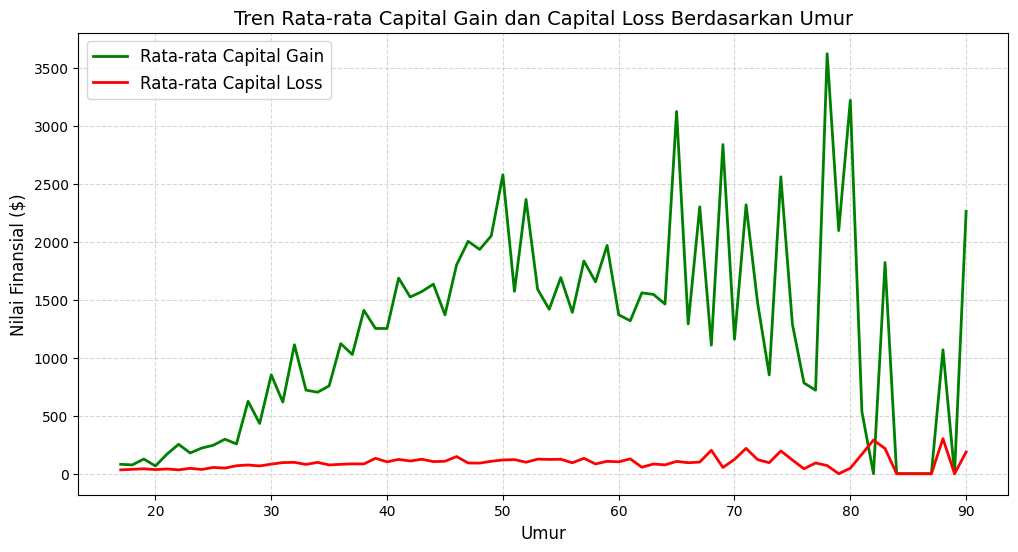

In [26]:
# Jawab 1.4 - Lineplot
age_grouped = df_imputed.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=age_grouped, x='age', y='capital-gain', label='Rata-rata Capital Gain', color='green', linewidth=2)
sns.lineplot(data=age_grouped, x='age', y='capital-loss', label='Rata-rata Capital Loss', color='red', linewidth=2)

plt.title('Tren Rata-rata Capital Gain dan Capital Loss Berdasarkan Umur', fontsize=14)
plt.xlabel('Umur', fontsize=12)
plt.ylabel('Nilai Finansial ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [46]:
# Jawab Soal 2 - Analisis Visual

for inc in df_imputed['income'].unique():
    sub_df = df_imputed[df_imputed['income'] == inc]['hours-per-week']
    q1 = sub_df.quantile(0.25)
    q3 = sub_df.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = sub_df[(sub_df < lower_bound) | (sub_df > upper_bound)]
    print(f"Kategori Income '{inc}':")
    print(f"  - Batas Bawah: {lower_bound}, Batas Atas: {upper_bound}")
    print(f"  - Jumlah Outlier: {len(outliers)} dari {len(sub_df)} data")

"""
1. Fenomena pada distribusi data umur ('age'):

   - Kalau diperhatikan, distribusi data umurnya membentuk pola right-skewed atau miring ke kanan.

   - Ini berarti mayoritas orang di dalam dataset ini adalah kalangan muda hingga paruh baya (berada di usia produktif sekitar 17 sampai 45 tahun). Puncak terbanyaknya ada di kisaran usia 30-an.

   - Nah, seiring bertambahnya umur, terutama untuk yang di atas 50 tahun, jumlah respondennya terlihat menurun drastis.

2. Strategi menangani data yang kosong (missing values) pada variabel 'age':

   - Strategi Terbaik: Cara paling pas adalah mengisi kekosongan data tersebut dengan nilai Median (nilai tengah).

   - Alasannya: Karena distribusi datanya tadi miring ke kanan (skewed). Kalau kita memaksakan pakai Mean (rata-rata), nilainya bakal rentan ketarik oleh angka-angka ekstrem (misalnya ada beberapa responden yang usianya sudah sangat tua). Penggunaan median jauh lebih kebal (robust) terhadap nilai ekstrem dan ketidaksimetrisan data.

   - Strategi Alternatif (Lebih detail): Kita juga bisa pakai trik imputasi berbasis kelompok. Contohnya, data umur yang kosong diisi menggunakan nilai median dari kelompok orang yang punya kesamaan latar belakang, seperti tingkat pendidikannya ('education') atau status pernikahannya ('marital-status').

3. Analisis Outlier pada jam kerja ('hours-per-week') berdasarkan kategori pemasukan ('income'):

   - Berdasarkan hitung-hitungan menggunakan metode IQR (Interquartile Range) tadi, kita bisa melihat pola ini:

   - Kelompok Income '<=50K': Kelompok ini punya outlier yang sangat banyak. Kenapa? Karena mayoritas pekerja di level ini punya jam kerja yang standar (sekitar 40 jam seminggu). Jadi, kalau ada yang kerjanya sangat sebentar (paruh waktu) atau malah lembur gila-gilaan, mereka otomatis akan terdeteksi sebagai outlier.

   - Kelompok Income '>50K': Di kelompok ini sebenarnya ada outlier juga. Tapi kalau dibandingkan secara proporsi maupun jumlah aslinya, kategori '<=50K' punya outlier yang jauh lebih banyak.
"""
print(__doc__)

Kategori Income '<=50K':
  - Batas Bawah: 27.5, Batas Atas: 47.5
  - Jumlah Outlier: 11706 dari 37155 data
Kategori Income '>50K':
  - Batas Bawah: 25.0, Batas Atas: 65.0
  - Jumlah Outlier: 781 dari 11687 data

1. Fenomena pada distribusi data umur ('age'):

   - Kalau kita perhatikan, distribusi data umurnya membentuk pola right-skewed atau miring ke kanan.

   - Ini berarti mayoritas orang di dalam dataset ini adalah kalangan muda hingga paruh baya (berada di usia produktif sekitar 17 sampai 45 tahun). Puncak terbanyaknya ada di kisaran usia 30-an.

   - Nah, seiring bertambahnya umur—terutama untuk yang di atas 50 tahun—jumlah respondennya terlihat menurun drastis.

2. Strategi menangani data yang kosong (missing values) pada variabel 'age':

   - Strategi Terbaik: Cara paling pas adalah mengisi kekosongan data tersebut dengan nilai Median (nilai tengah).

   - Alasannya: Karena distribusi datanya tadi miring ke kanan (skewed). Kalau kita memaksakan pakai Mean (rata-rata), nilainya

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [35]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

df_imputed['sex_encoded'] = df_imputed['sex'].map({'Female': 0, 'Male': 1})

df_imputed['income_encoded'] = df_imputed['income'].map({'<=50K': 0, '>50K': 1})

print("Hasil Encoding Kolom 'sex'")
display(df_imputed[['sex', 'sex_encoded']].drop_duplicates())

print("\nHasil Encoding Kolom 'income'")
display(df_imputed[['income', 'income_encoded']].drop_duplicates())

print("\nTipe data setelah encoding:")
print(df_imputed[['sex_encoded', 'income_encoded']].dtypes)

Hasil Encoding Kolom 'sex'


,sex,sex_encoded
0,Male,1
4,Female,0



Hasil Encoding Kolom 'income'


,income,income_encoded
0,<=50K,0
7,>50K,1



Tipe data setelah encoding:
sex_encoded       int64
income_encoded    int64
dtype: object


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

In [38]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

columns_to_correlate = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income_encoded']
correlation_matrix = df_imputed[columns_to_correlate].corr()

print("Matriks Korelasi Pearson")
display(correlation_matrix.round(3))

Matriks Korelasi Pearson


,age,education-num,hours-per-week,capital-gain,capital-loss,income_encoded
age,1.000,0.031,0.072,0.077,0.057,0.230
education-num,0.031,1.000,0.144,0.125,0.081,0.333
hours-per-week,0.072,0.144,1.000,0.082,0.054,0.228
capital-gain,0.077,0.125,0.082,1.000,-0.031,0.223
capital-loss,0.057,0.081,0.054,-0.031,1.000,0.148
income_encoded,0.230,0.333,0.228,0.223,0.148,1.000


In [51]:
# Hasil analisis jelaskan pada cell ini

"""
HASIL ANALISIS KORELASI

Kalau diperhatikan dari tabel korelasi Pearson, ada beberapa poin menarik:

1. Siapa yang Paling Berpengaruh Terhadap Pendapatan (income_encoded)?
   - Ternyata, tingkat pendidikan ('education-num') memegang peran paling kuat di sini dengan korelasi positif sekitar 0.333. Artinya, semakin tinggi sekolah atau pendidikan formal yang ditempuh seseorang, peluangnya untuk mendapatkan pemasukan di atas $50K juga semakin besar.
   - Di posisi kedua dan ketiga, ada faktor usia ('age') dengan nilai 0.230 dan jam kerja per minggu ('hours-per-week') sebesar 0.228. Hal ini sangat masuk akal, karena semakin bertambah umur biasanya pengalaman kerja kita bertambah (gaji naik), dan orang yang bekerja dengan jam kerja lebih lama cenderung menghasilkan lebih banyak uang.
   - Sementara itu, 'capital-gain' (0.223) dan 'capital-loss' (0.148) juga punya hubungan searah, tapi pengaruhnya tidak sekuat faktor pendidikan atau usia.

2. Hubungan Antar-Variabel Bebas (Apakah ada yang tumpang tindih?):
   - Kalau dilihat dari hubungan antara sesama variabel independen (seperti umur dengan jam kerja, atau pendidikan dengan capital gain), nilai hubungannya kecil sekali (semuanya di bawah 0.15).
   - Ini tanda yang sangat bagus untuk pemodelan data! Artinya tidak ada gejala "multikolinearitas" (kondisi di mana dua variabel bebas saling mendominasi atau menduplikasi informasi satu sama lain). Jadi, semua fitur ini aman dan sangat bagus kalau dipakai barengan nanti.

Kesimpulan Sederhana:
Kalau mau menebak apakah seseorang punya penghasilan tinggi (di atas $50K) berdasarkan data ini, tiga modal utama yang paling menentukan adalah seberapa tinggi pendidikannya, seberapa matang usianya, dan seberapa giat dia bekerja dalam seminggu.
"""

print(__doc__)


HASIL ANALISIS KORELASI

Kalau diperhatikan dari tabel korelasi Pearson, ada beberapa poin menarik:

1. Siapa yang Paling Berpengaruh Terhadap Pendapatan (income_encoded)?
   - Ternyata, tingkat pendidikan ('education-num') memegang peran paling kuat di sini dengan korelasi positif sekitar 0.333. Artinya, semakin tinggi sekolah atau pendidikan formal yang ditempuh seseorang, peluangnya untuk mendapatkan pemasukan di atas $50K juga semakin besar. 
   - Di posisi kedua dan ketiga, ada faktor usia ('age') dengan nilai 0.230 dan jam kerja per minggu ('hours-per-week') sebesar 0.228. Hal ini sangat masuk akal, karena semakin bertambah umur biasanya pengalaman kerja kita bertambah (gaji naik), dan orang yang bekerja dengan jam kerja lebih lama cenderung menghasilkan lebih banyak uang.
   - Sementara itu, 'capital-gain' (0.223) dan 'capital-loss' (0.148) juga punya hubungan searah, tapi pengaruhnya tidak sekuat faktor pendidikan atau usia.

2. Hubungan Antar-Variabel Bebas (Apakah ada yang t

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [52]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


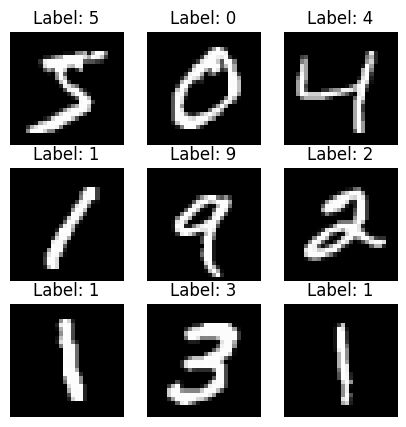

In [53]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Ukuran data X_test sebelum upsampling: (10000, 28, 28)
Ukuran data X_test setelah upsampling: (10000, 32, 32)


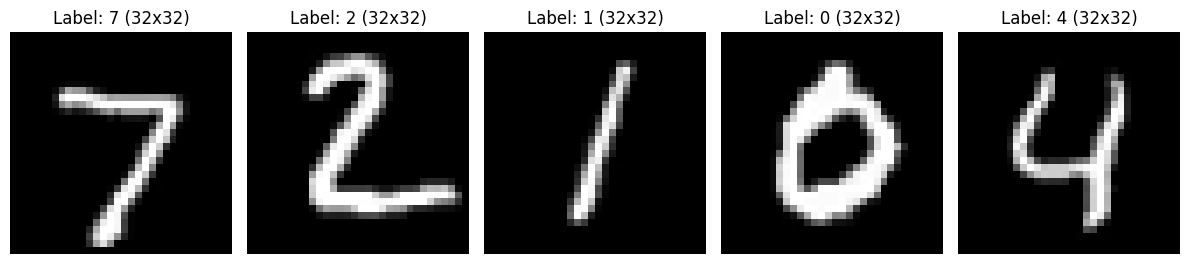

In [55]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
import cv2
import numpy as np
import matplotlib.pyplot as plt

X_test_resized = np.zeros((X_test.shape[0], 32, 32), dtype=X_test.dtype)

for i in range(X_test.shape[0]):
    X_test_resized[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_CUBIC)

print("Ukuran data X_test sebelum upsampling:", X_test.shape)
print("Ukuran data X_test setelah upsampling:", X_test_resized.shape)

plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_resized[i], cmap="gray")
    plt.title(f"Label: {y_test[i]} (32x32)")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [75]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

X_test_normalized = X_test_resized.astype('float32') / 255.0

print("Ukuran data setelah normalisasi:", X_test_normalized.shape)
print("Nilai piksel minimum:", X_test_normalized.min())
print("Nilai piksel maksimum:", X_test_normalized.max())

print("\nCuplikan nilai piksel gambar indeks ke-0 (baris indeks ke-16, kolom 10-25):")
print(X_test_normalized[0][16][10:25])

Ukuran data setelah normalisasi: (10000, 32, 32)
Nilai piksel minimum: 0.0
Nilai piksel maksimum: 1.0

Cuplikan nilai piksel gambar indeks ke-0 (baris indeks ke-16, kolom 10-25):
[0.         0.         0.         0.         0.         0.
 0.         0.         0.0627451  0.6431373  1.         0.8156863
 0.17254902 0.         0.        ]


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [74]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

num_samples = X_test_normalized.shape[0]
num_features = 32 * 32  # 1024
X_test_flattened = np.zeros((num_samples, num_features), dtype=X_test_normalized.dtype)

for i in range(num_samples):
    X_test_flattened[i] = X_test_normalized[i].flatten()

print("Array 1 dimensi (citra indeks ke-0, 50 piksel pertama):")
print(X_test_flattened[0][:50])

print("\nUkuran awal data test:", X_test_normalized.shape)
print("Ukuran data setelah di-flatten ke holder array:", X_test_flattened.shape)
print("Panjang vektor satu citra:", X_test_flattened.shape[1], "piksel")

Array 1 dimensi (citra indeks ke-0, 50 piksel pertama):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

Ukuran awal data test: (10000, 32, 32)
Ukuran data setelah di-flatten ke holder array: (10000, 1024)
Panjang vektor satu citra: 1024 piksel
